In [1]:
!pip install nltk spacy contractions unidecode
!python -m nltk.downloader stopwords punkt wordnet omw-1.4
!python -m spacy download en_core_web_sm

<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 41.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.utils import resample
import matplotlib.pyplot as plt

In [3]:

# baseline
# Load data
train_df = pd.read_csv('/content/train_ecommerceDataset.csv')
test_df = pd.read_csv('/content/test_ecommerceDataset.csv')

X_train_text = train_df['description']
y_train = train_df['category']
X_test_text = test_df['description']
y_test = test_df['category']

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier()
gbc.fit(X_train_tfidf, y_train)

y_pred = gbc.predict(X_test_tfidf)

# Evaluation
print("🚩 Baseline Performance (Gradient Boosting):")
print(classification_report(y_test, y_pred, digits=6))


🚩 Baseline Performance (Gradient Boosting):
                        precision    recall  f1-score   support

                 Books   0.920814  0.867804  0.893524       469
Clothing & Accessories   0.937126  0.909884  0.923304       344
           Electronics   0.961749  0.836105  0.894536       421
             Household   0.846154  0.947781  0.894089       766

              accuracy                       0.899000      2000
             macro avg   0.916461  0.890393  0.901363      2000
          weighted avg   0.903642  0.899000  0.899075      2000



In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(set(y_true)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(set(y_true)))
    disp.plot(xticks_rotation=45, cmap='Blues')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [5]:
# text cleaning

import re
import string
import contractions
import unidecode
import nltk
import spacy
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize

# Load NLP tools
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words("english"))
stemmer = SnowballStemmer("english")

# Optional: define custom acronyms
acronym_dict = {
    "tv": "television",
    "usb": "universal serial bus",
    # add more if needed
}

def normalize_text(text):
    if not isinstance(text, str):
        return ""

    # Expand contractions
    text = contractions.fix(text)

    # Normalize unicode
    text = unidecode.unidecode(text)

    # Lowercase
    text = text.lower()

    # Remove extra whitespaces
    text = re.sub(r"\s+", " ", text).strip()

    # Replace acronyms
    for acro, full in acronym_dict.items():
        text = re.sub(r'\b{}\b'.format(acro), full, text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenize and POS tagging
    doc = nlp(text)

    clean_tokens = []
    for token in doc:
        if (
            token.text.isalpha() and                 # keep alphabetic
            token.text not in stop_words and         # remove stopwords
            token.pos_ in {"NOUN", "ADJ", "VERB"}    # keep important parts of speech
        ):
            lemma = token.lemma_.strip()
            if len(lemma) > 2:
                clean_tokens.append(lemma)

    return " ".join(clean_tokens)
# Load and drop null

train_df = pd.read_csv('/content/train_ecommerceDataset.csv').dropna(subset=['description'])
test_df = pd.read_csv('/content/test_ecommerceDataset.csv').dropna(subset=['description'])

# Apply cleaning function
train_df['cleaned_desc'] = train_df['description'].apply(normalize_text)
test_df['cleaned_desc'] = test_df['description'].apply(normalize_text)

X_train = train_df['cleaned_desc']
y_train = train_df['category']
X_test = test_df['cleaned_desc']
y_test = test_df['category']

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

gbc = GradientBoostingClassifier()
gbc.fit(X_train_tfidf, y_train)
y_pred_cleaned = gbc.predict(X_test_tfidf)

print("🚩 Performance After Full Text Preprocessing:")
print(classification_report(y_test, y_pred_cleaned, digits=6))


🚩 Performance After Full Text Preprocessing:
                        precision    recall  f1-score   support

                 Books   0.955801  0.737740  0.832732       469
Clothing & Accessories   0.938907  0.848837  0.891603       344
           Electronics   0.949861  0.809976  0.874359       421
             Household   0.761364  0.962141  0.850058       766

              accuracy                       0.858000      2000
             macro avg   0.901483  0.839674  0.862188      2000
          weighted avg   0.877175  0.858000  0.858256      2000



In [6]:
# undersampling / reduce class imbalance

min_count = train_df['category'].value_counts().min()

df_downsampled = pd.DataFrame()
for label in train_df['category'].unique():
    subset = train_df[train_df['category'] == label]
    downsampled = resample(subset, replace=False, n_samples=min_count, random_state=42)
    df_downsampled = pd.concat([df_downsampled, downsampled])

df_downsampled = df_downsampled.sample(frac=1, random_state=42).reset_index(drop=True)

df_downsampled['cleaned_desc'] = df_downsampled['description'].apply(normalize_text)
test_df['cleaned_desc'] = test_df['description'].apply(normalize_text)

X_train = df_downsampled['cleaned_desc']
y_train = df_downsampled['category']
X_test = test_df['cleaned_desc']
y_test = test_df['category']

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

gbc = GradientBoostingClassifier()
gbc.fit(X_train_tfidf, y_train)
y_pred_undersample = gbc.predict(X_test_tfidf)

print("🚩 Performance after Undersampling + Preprocessing:")
print(classification_report(y_test, y_pred_undersample, digits=6))

🚩 Performance after Undersampling + Preprocessing:
                        precision    recall  f1-score   support

                 Books   0.939474  0.761194  0.840989       469
Clothing & Accessories   0.894428  0.886628  0.890511       344
           Electronics   0.897311  0.871734  0.884337       421
             Household   0.808046  0.917755  0.859413       766

              accuracy                       0.866000      2000
             macro avg   0.884815  0.859328  0.868813      2000
          weighted avg   0.872514  0.866000  0.865688      2000



In [7]:
# oversampling
train_df = pd.read_csv('/content/train_ecommerceDataset.csv').dropna(subset=['description'])
test_df = pd.read_csv('/content/test_ecommerceDataset.csv').dropna(subset=['description'])


target_count = train_df['category'].value_counts().max()
df_oversampled = pd.DataFrame()

for label in train_df['category'].unique():
    subset = train_df[train_df['category'] == label]
    upsampled = resample(subset, replace=True, n_samples=target_count, random_state=42)
    df_oversampled = pd.concat([df_oversampled, upsampled])

df_oversampled = df_oversampled.sample(frac=1, random_state=42).reset_index(drop=True)

df_oversampled['cleaned_desc'] = df_oversampled['description'].apply(normalize_text)
test_df['cleaned_desc'] = test_df['description'].apply(normalize_text)

X_train = df_oversampled['cleaned_desc']
y_train = df_oversampled['category']
X_test = test_df['cleaned_desc']
y_test = test_df['category']

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = GradientBoostingClassifier()
model.fit(X_train_tfidf, y_train)
y_pred_oversample = model.predict(X_test_tfidf)

print("🚩 Performance After Oversampling + Preprocessing:")
print(classification_report(y_test, y_pred_oversample, digits=6))

🚩 Performance After Oversampling + Preprocessing:
                        precision    recall  f1-score   support

                 Books   0.932817  0.769723  0.843458       469
Clothing & Accessories   0.892754  0.895349  0.894049       344
           Electronics   0.873786  0.855107  0.864346       421
             Household   0.811916  0.907311  0.856967       766

              accuracy                       0.862000      2000
             macro avg   0.877818  0.856872  0.864705      2000
          weighted avg   0.867195  0.862000  0.861730      2000



In [8]:
# hybrid

train_df = pd.read_csv('/content/train_ecommerceDataset.csv').dropna(subset=['description'])

# Category distribution
class_counts = train_df['category'].value_counts()
mean_size = class_counts.mean()
rare_threshold = 0.5 * mean_size  # you can tweak this

# Create empty holder
df_hybrid = pd.DataFrame()

# Balance strategy
for label in class_counts.index:
    subset = train_df[train_df['category'] == label]
    count = class_counts[label]

    if count > mean_size:
        # Undersample majority
        sampled = resample(subset, replace=False, n_samples=int(mean_size), random_state=42)
    elif count < rare_threshold:
        # Oversample minority
        sampled = resample(subset, replace=True, n_samples=int(rare_threshold), random_state=42)
    else:
        # Leave medium classes as is
        sampled = subset

    df_hybrid = pd.concat([df_hybrid, sampled])

# Shuffle and preprocess
df_hybrid = df_hybrid.sample(frac=1, random_state=42).reset_index(drop=True)
df_hybrid['cleaned_desc'] = df_hybrid['description'].apply(normalize_text)

# TF-IDF and Train
X_train = df_hybrid['cleaned_desc']
y_train = df_hybrid['category']
X_test = test_df['cleaned_desc']
y_test = test_df['category']

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model.fit(X_train_tfidf, y_train)
y_pred_hybrid = model.predict(X_test_tfidf)

print("🚩 Performance After Hybrid Resampling + Preprocessing:")
print(classification_report(y_test, y_pred_hybrid, digits=6))

🚩 Performance After Hybrid Resampling + Preprocessing:
                        precision    recall  f1-score   support

                 Books   0.882231  0.910448  0.896118       469
Clothing & Accessories   0.928793  0.872093  0.899550       344
           Electronics   0.904645  0.878860  0.891566       421
             Household   0.885204  0.906005  0.895484       766

              accuracy                       0.895500      2000
             macro avg   0.900218  0.891851  0.895679      2000
          weighted avg   0.896097  0.895500  0.895507      2000



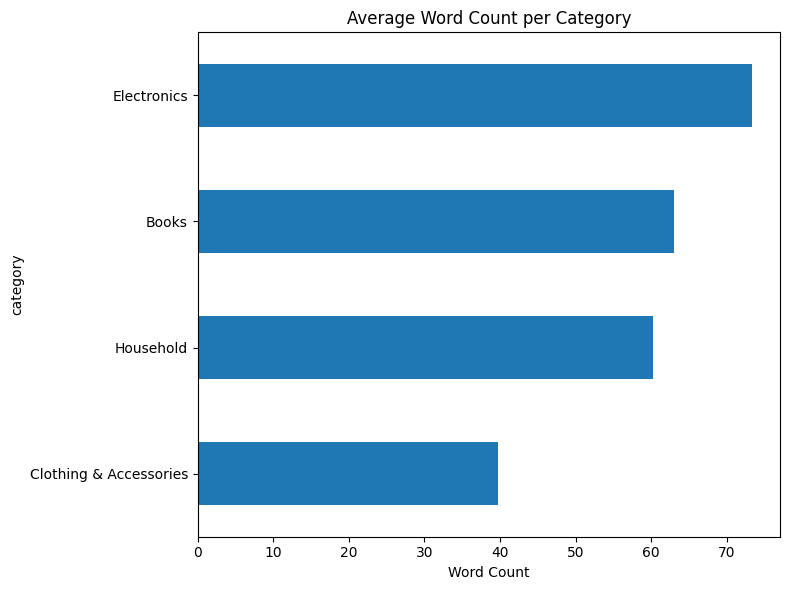

Overall Average Word Count: 59.11


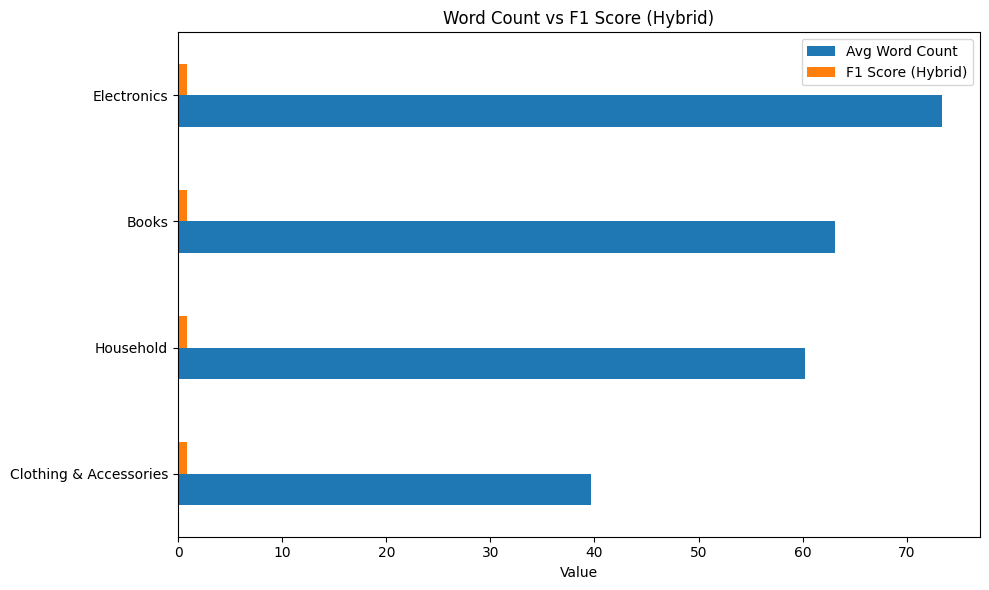

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Step 1: Add word count to test set
test_df['word_count'] = test_df['cleaned_desc'].apply(lambda x: len(x.split()))

# Step 2: Compute average word count per category
wordcount_by_class = test_df.groupby('category')['word_count'].mean().sort_values()

# Step 3: Plot average word count per category
plt.figure(figsize=(8, 6))
wordcount_by_class.plot(kind='barh', title="Average Word Count per Category")
plt.xlabel("Word Count")
plt.tight_layout()
plt.show()

# Step 4: Extract F1 scores from hybrid model
report = classification_report(y_test, y_pred_hybrid, output_dict=True)
f1_scores = {k: v['f1-score'] for k, v in report.items() if k in test_df['category'].unique()}

# Step 5: Combine word count and F1 into a dataframe
word_perf_df = pd.DataFrame({
    'Avg Word Count': wordcount_by_class,
    'F1 Score (Hybrid)': pd.Series(f1_scores)
}).dropna()

# Step 6: Compute and print overall average word count
overall_avg = word_perf_df['Avg Word Count'].mean()
print(f"Overall Average Word Count: {overall_avg:.2f}")

# Step 7: Plot combined view
word_perf_df.sort_values("Avg Word Count").plot(kind='barh', figsize=(10, 6), title="Word Count vs F1 Score (Hybrid)")
plt.xlabel("Value")
plt.tight_layout()
plt.show()


In [14]:
word_perf_df

,Avg Word Count,F1 Score (Hybrid)
Books,63.072495,0.896118
Clothing & Accessories,39.712209,0.899550
Electronics,73.375297,0.891566
Household,60.278068,0.895484


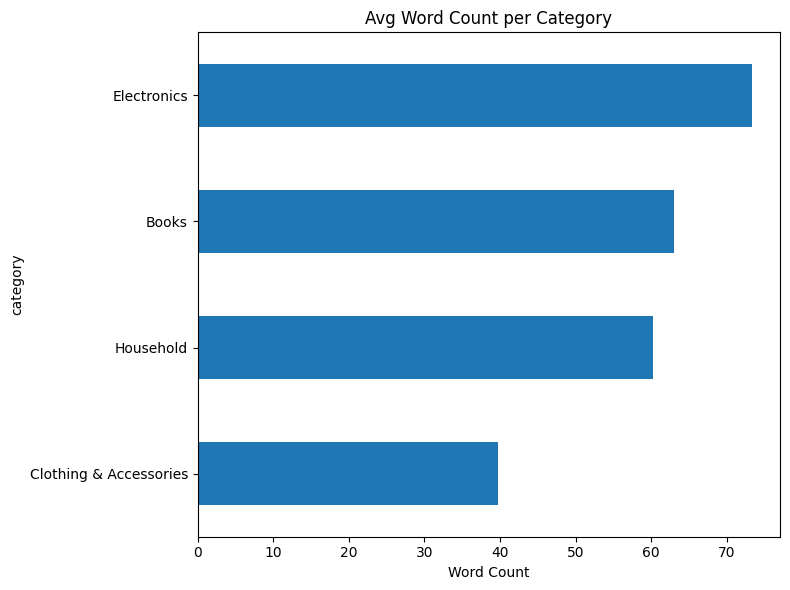

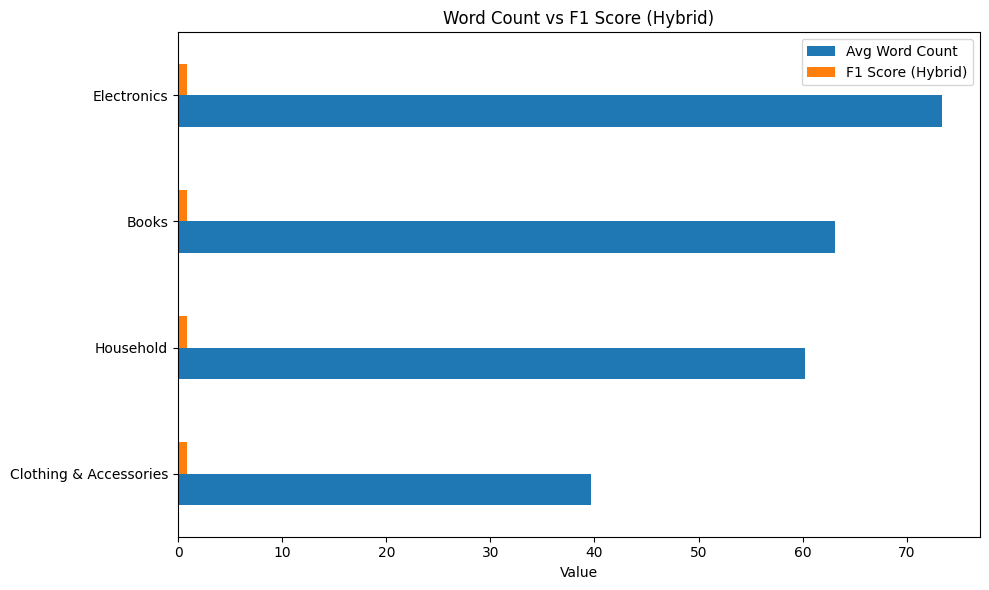

In [9]:
# Add word count
test_df['word_count'] = test_df['cleaned_desc'].apply(lambda x: len(x.split()))

# Avg word count per category
wordcount_by_class = test_df.groupby('category')['word_count'].mean().sort_values()

# Plot
wordcount_by_class.plot(kind='barh', figsize=(8,6), title="Avg Word Count per Category")
plt.xlabel("Word Count")
plt.tight_layout()
plt.show()

from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Get report from hybrid model
report = classification_report(y_test, y_pred_hybrid, output_dict=True)
f1_scores = {k: v['f1-score'] for k, v in report.items() if k in test_df['category'].unique()}

# Combine into one DataFrame
word_perf_df = pd.DataFrame({
    'Avg Word Count': wordcount_by_class,
    'F1 Score (Hybrid)': pd.Series(f1_scores)
}).dropna()

# Plot combined view
word_perf_df.sort_values("Avg Word Count").plot(kind='barh', figsize=(10, 6), title="Word Count vs F1 Score (Hybrid)")
plt.xlabel("Value")
plt.tight_layout()
plt.show()


In [10]:
# PCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# STEP 1: PCA on Hybrid TF-IDF Data
X_pca = PCA(n_components=2).fit_transform(X_train_tfidf.toarray())

# STEP 2: Detect Outliers (2.5 std deviation from mean)
x_mean, y_mean = np.mean(X_pca, axis=0)
x_std, y_std = np.std(X_pca, axis=0)

inliers_mask = (
    (np.abs(X_pca[:, 0] - x_mean) < 2.5 * x_std) &
    (np.abs(X_pca[:, 1] - y_mean) < 2.5 * y_std)
)

# STEP 3: Filter Outliers
X_train_inliers = X_train.reset_index(drop=True)[inliers_mask]
y_train_inliers = y_train.reset_index(drop=True)[inliers_mask]

# Re-vectorize
X_train_tfidf_cleaned = vectorizer.fit_transform(X_train_inliers)
X_test_tfidf = vectorizer.transform(X_test)

# Retrain model
model.fit(X_train_tfidf_cleaned, y_train_inliers)
y_pred_pca_cleaned = model.predict(X_test_tfidf)

# STEP 4: Performance Report
print("🚩 Performance After PCA Outlier Removal:")
print(classification_report(y_test, y_pred_pca_cleaned, digits=6))

🚩 Performance After PCA Outlier Removal:
                        precision    recall  f1-score   support

                 Books   0.884058  0.910448  0.897059       469
Clothing & Accessories   0.920973  0.880814  0.900446       344
           Electronics   0.922500  0.876485  0.898904       421
             Household   0.885787  0.911227  0.898327       766

              accuracy                       0.898500      2000
             macro avg   0.903329  0.894743  0.898684      2000
          weighted avg   0.899161  0.898500  0.898515      2000



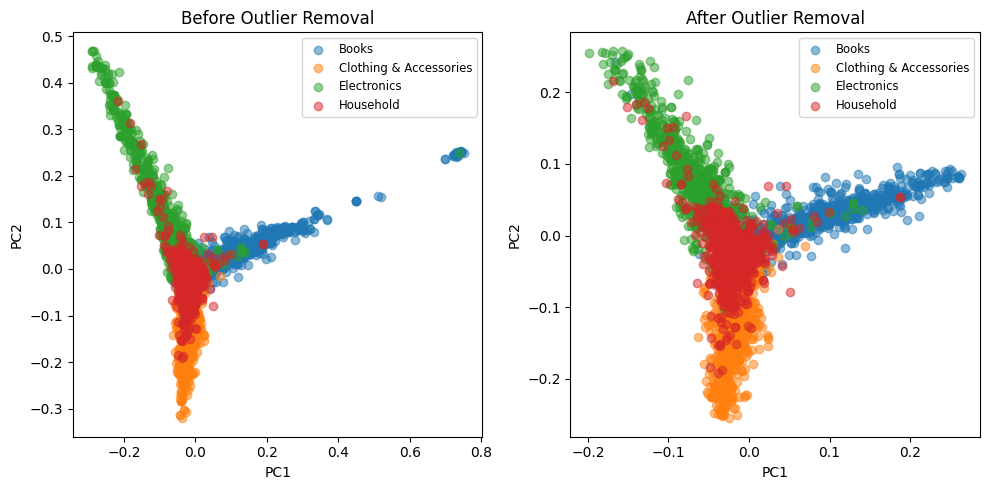

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# Step 1: PCA projection
X_pca = PCA(n_components=2).fit_transform(X_train_tfidf.toarray())
y_train_array = y_train.reset_index(drop=True).values

# Step 2: Outlier detection
x_mean, y_mean = np.mean(X_pca, axis=0)
x_std, y_std = np.std(X_pca, axis=0)

inliers_mask = (
    (np.abs(X_pca[:, 0] - x_mean) < 2.5 * x_std) &
    (np.abs(X_pca[:, 1] - y_mean) < 2.5 * y_std)
)

X_pca_cleaned = X_pca[inliers_mask]
y_train_cleaned = y_train_array[inliers_mask]

# Step 3: Plot with class labels
plt.figure(figsize=(10, 5))

# Before outlier removal
plt.subplot(1, 2, 1)
for label in np.unique(y_train_array):
    idx = y_train_array == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.5)
plt.title("Before Outlier Removal")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(fontsize='small')

# After outlier removal
plt.subplot(1, 2, 2)
for label in np.unique(y_train_cleaned):
    idx = y_train_cleaned == label
    plt.scatter(X_pca_cleaned[idx, 0], X_pca_cleaned[idx, 1], label=label, alpha=0.5)
plt.title("After Outlier Removal")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(fontsize='small')

plt.tight_layout()
plt.show()


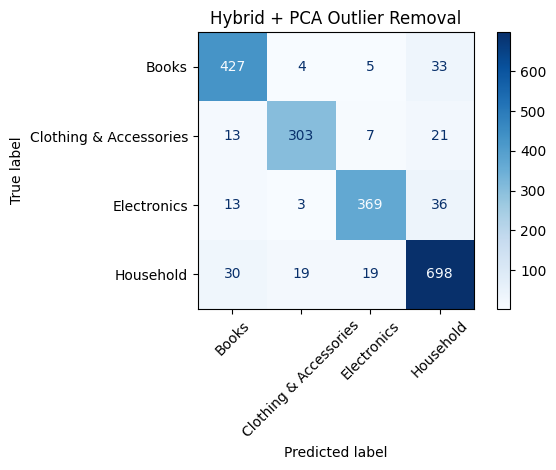

In [12]:
# STEP 6: Optional - Confusion Matrix
cm = confusion_matrix(y_test, y_pred_pca_cleaned, labels=sorted(set(y_test)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(set(y_test)))
disp.plot(xticks_rotation=45, cmap='Blues')
plt.title("Hybrid + PCA Outlier Removal")
plt.tight_layout()
plt.show()

In [9]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
import pandas as pd

# Models with different n_estimators
estimators = [50, 100, 200]
models = [GradientBoostingClassifier(n_estimators=n, random_state=42) for n in estimators]

# Prepare cleaned TF-IDF and labels (after PCA outlier removal)
X_cleaned = X_train_tfidf_cleaned  # sparse matrix
y_cleaned = y_train_inliers.reset_index(drop=True)

# 2-Fold Stratified Cross Validation
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

results = {}

for model in models:
    model_name = f"GradientBoosting_n={model.n_estimators}"
    fold_reports = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_cleaned, y_cleaned), start=1):
        X_train_fold = X_cleaned[train_idx]
        y_train_fold = y_cleaned.iloc[train_idx]
        X_val_fold = X_cleaned[val_idx]
        y_val_fold = y_cleaned.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_pred_fold = model.predict(X_val_fold)
        report = classification_report(y_val_fold, y_pred_fold, output_dict=True)
        fold_reports.append(report)
        print(f"Fold {fold_idx}: {model_name}")
        print(classification_report(y_val_fold, y_pred_fold, digits=6))

    results[model_name] = fold_reports

# Summary: Average F1-score across folds for each class
summary = {}
for model_name, reports in results.items():
    avg_f1 = {}
    for label in reports[0].keys():
        if isinstance(reports[0][label], dict) and "f1-score" in reports[0][label]:
            f1_scores = [r[label]["f1-score"] for r in reports if label in r]
            avg_f1[label] = sum(f1_scores) / len(f1_scores)
    summary[model_name] = avg_f1

df_summary = pd.DataFrame(summary).T
print("📊 Average F1-Score per Class Across 2 Folds:\n")
print(df_summary.round(4))


Fold 1: GradientBoosting_n=50
                        precision    recall  f1-score   support

                 Books   0.944976  0.723443  0.819502       546
Clothing & Accessories   0.939474  0.850000  0.892500       420
           Electronics   0.901478  0.785408  0.839450       466
             Household   0.677230  0.924679  0.781843       624

              accuracy                       0.824416      2056
             macro avg   0.865789  0.820883  0.833324      2056
          weighted avg   0.852732  0.824416  0.827506      2056

Fold 2: GradientBoosting_n=50
                        precision    recall  f1-score   support

                 Books   0.847199  0.915596  0.880071       545
Clothing & Accessories   0.910843  0.897862  0.904306       421
           Electronics   0.883951  0.768240  0.822044       466
             Household   0.801858  0.831461  0.816391       623

              accuracy                       0.853041      2055
             macro avg   0.860963  0.85

In [ ]:
result_50 = [0.824416, 0.853041]
result_100 = [0.843385, 0.868127]
result_200 = [0.875973, 0.881265]

In [10]:
from scipy.stats import ttest_rel

# F1 scores across 2 folds
result_50 = [0.824416, 0.853041]
result_100 = [0.843385, 0.868127]
result_200 = [0.875973, 0.881265]

# Paired t-test: 100 vs 50
t_stat_100_50, p_val_100_50 = ttest_rel(result_100, result_50)
print("Paired t-test: 100 vs 50")
print(f"T-statistic: {t_stat_100_50:.4f}, P-value: {p_val_100_50:.4f}\n")

# Paired t-test: 100 vs 200
t_stat_100_200, p_val_100_200 = ttest_rel(result_100, result_200)
print("Paired t-test: 100 vs 200")
print(f"T-statistic: {t_stat_100_200:.4f}, P-value: {p_val_100_200:.4f}")


Paired t-test: 100 vs 50
T-statistic: 8.7703, P-value: 0.0723

Paired t-test: 100 vs 200
T-statistic: -2.3510, P-value: 0.2560
